# NEMSIS Cardiac-Arrest ROSC Prediction

## Machine Learning Capstone

This notebook evaluates whether EMS system response time adds predictive value for return of spontaneous circulation (ROSC) among out-of-hospital cardiac-arrest activations. It analyzes both a broad attempted-resuscitation cohort and a classic presumed-cardiac Utstein-style subgroup.

**Research question:** Does adding EMS system response time improve cross-validated prediction of ROSC beyond age, geography, arrest etiology, witness category, pre-arrival AED use, and initial rhythm?

**Important interpretation:** This is a predictive association study. It does not estimate a causal effect of response time.

**Data source credit:** National Highway Traffic Safety Administration, National Emergency Medical Services Information System (NEMSIS). Derived content remains NHTSA property. NHTSA is not responsible for claims arising from this analysis. See the [NEMSIS RDS User Manual](https://nemsis.org/wp-content/uploads/2025/09/2024-NEMSIS-RDS-350-User-Manual-v3.pdf).


## 1. Setup and data loading

The local row-level CSV is intentionally excluded from Git because the NEMSIS research-data terms restrict redistribution. The preparation script in this repository reproduces the modeling dataset from an authorized local NEMSIS extract.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("data/nemsis_cardiac_arrest_modeling.csv")
FIGURES_DIR = Path("figures")
RESULTS_DIR = Path("results")
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42


In [2]:
required_columns = {
    "rosc",
    "response_time_minutes",
    "age_years",
    "urbanicity",
    "census_region",
    "arrest_etiology",
    "witness_category",
    "aed_use_prior_ems",
    "initial_rhythm",
    "utstein_style",
    "classic_utstein",
}

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Run prepare_modeling_dataset.py first."
    )

df = pd.read_csv(DATA_PATH)
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"ROSC positive: {df['rosc'].sum():,} ({df['rosc'].mean():.2%})")
display(df.head())


Rows: 17,198
Columns: 13
ROSC positive: 5,097 (29.64%)


,rosc,response_time_minutes,age_years,urbanicity,census_region,arrest_etiology,witness_category,aed_use_prior_ems,initial_rhythm,bystander_witnessed,shockable_rhythm,utstein_style,classic_utstein
0,0,2.000000,98.0,Rural,South,Cardiac (presumed),Not witnessed,No AED,Asystole,0,0,0,0
1,0,3.000000,64.0,Rural,Northeast,Traumatic cause,Healthcare provider,No AED,Unknown AED non-shockable rhythm,1,0,0,0
2,0,7.933333,76.0,Urban,West,Cardiac (presumed),Bystander,Applied with defibrillation,Asystole,1,0,0,0
3,0,3.583333,44.0,Urban,Northeast,Drug overdose,Not witnessed,No AED,Asystole,0,0,0,0
4,1,7.166667,82.0,Urban,West,Cardiac (presumed),Not witnessed,No AED,PEA,0,0,0,0


## 2. Cohort and data-quality review

The broad cohort requires documented cardiac arrest before EMS arrival, attempted EMS resuscitation, a known ROSC outcome, the reporting unit marked as first EMS unit on scene, primary-area emergency response, and a recorded system response time.

The classic Utstein-style subgroup further requires a clean bystander-witnessed arrest, a shockable first monitored rhythm, and presumed cardiac etiology. The outcome remains ROSC—not survival to hospital discharge—so this notebook does not label the measure “Utstein survival.”


In [3]:
cohort_summary = pd.DataFrame(
    {
        "cohort": ["Broad", "Utstein-style", "Classic Utstein"],
        "records": [len(df), int(df['utstein_style'].sum()), int(df['classic_utstein'].sum())],
        "rosc_positive": [
            int(df['rosc'].sum()),
            int(df.loc[df['utstein_style'].eq(1), 'rosc'].sum()),
            int(df.loc[df['classic_utstein'].eq(1), 'rosc'].sum()),
        ],
    }
)
cohort_summary["rosc_rate_pct"] = (
    100 * cohort_summary["rosc_positive"] / cohort_summary["records"]
).round(2)
display(cohort_summary)

quality_summary = pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_pct": (100 * df.isna().mean()).round(2),
    }
).sort_values("missing_count", ascending=False)
display(quality_summary)


,cohort,records,rosc_positive,rosc_rate_pct
0,Broad,17198,5097,29.64
1,Utstein-style,2054,1093,53.21
2,Classic Utstein,1777,958,53.91


,missing_count,missing_pct
age_years,178,1.04
rosc,0,0.00
response_time_minutes,0,0.00
urbanicity,0,0.00
census_region,0,0.00
arrest_etiology,0,0.00
witness_category,0,0.00
aed_use_prior_ems,0,0.00
initial_rhythm,0,0.00
bystander_witnessed,0,0.00


In [4]:
response_summary = df['response_time_minutes'].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)
display(response_summary.to_frame("response_time_minutes"))
print("Zero-minute records:", int(df['response_time_minutes'].eq(0).sum()))
print("Records over 60 minutes:", int(df['response_time_minutes'].gt(60).sum()))


,response_time_minutes
count,17198.000000
mean,6.905186
std,4.695473
min,0.000000
1%,0.833333
5%,2.150000
25%,4.066667
50%,5.833333
75%,8.300000
95%,15.435833


Zero-minute records: 60
Records over 60 minutes: 3


## 3. Exploratory analysis

In [5]:
def response_decile_summary(data):
    working = data[["response_time_minutes", "rosc"]].dropna().copy()
    working["response_decile"] = (
        pd.qcut(
            working["response_time_minutes"],
            q=10,
            labels=False,
            duplicates="drop",
        )
        + 1
    )
    return (
        working.groupby("response_decile", observed=False)
        .agg(
            records=("rosc", "size"),
            median_minutes=("response_time_minutes", "median"),
            maximum_minutes=("response_time_minutes", "max"),
            rosc_rate_pct=("rosc", lambda values: 100 * values.mean()),
        )
        .reset_index()
    )

broad_deciles = response_decile_summary(df)
classic_df = df.loc[df["classic_utstein"].eq(1)].copy()
classic_deciles = response_decile_summary(classic_df)

print("Broad cohort response-time deciles")
display(broad_deciles.round(2))
print("Classic Utstein response-time deciles")
display(classic_deciles.round(2))


Broad cohort response-time deciles


,response_decile,records,median_minutes,maximum_minutes,rosc_rate_pct
0,1,1740,2.17,2.98,32.13
1,2,1719,3.38,3.82,30.60
2,3,1722,4.08,4.45,31.94
3,4,1720,4.82,5.05,30.00
4,5,1719,5.45,5.83,29.38
5,6,1719,6.10,6.57,31.59
6,7,1713,7.00,7.67,29.89
7,8,1713,8.32,9.13,30.59
8,9,1718,10.32,12.00,27.07
9,10,1715,15.45,153.02,23.15


Classic Utstein response-time deciles


,response_decile,records,median_minutes,maximum_minutes,rosc_rate_pct
0,1,178,2.06,2.97,62.92
1,2,179,3.40,3.75,62.01
2,3,177,4.02,4.30,57.06
3,4,178,4.73,5.02,55.62
4,5,180,5.42,5.82,53.89
5,6,174,6.03,6.45,48.28
6,7,178,6.98,7.53,47.75
7,8,177,8.32,9.17,55.37
8,9,182,10.22,12.00,52.20
9,10,174,14.66,55.00,43.68


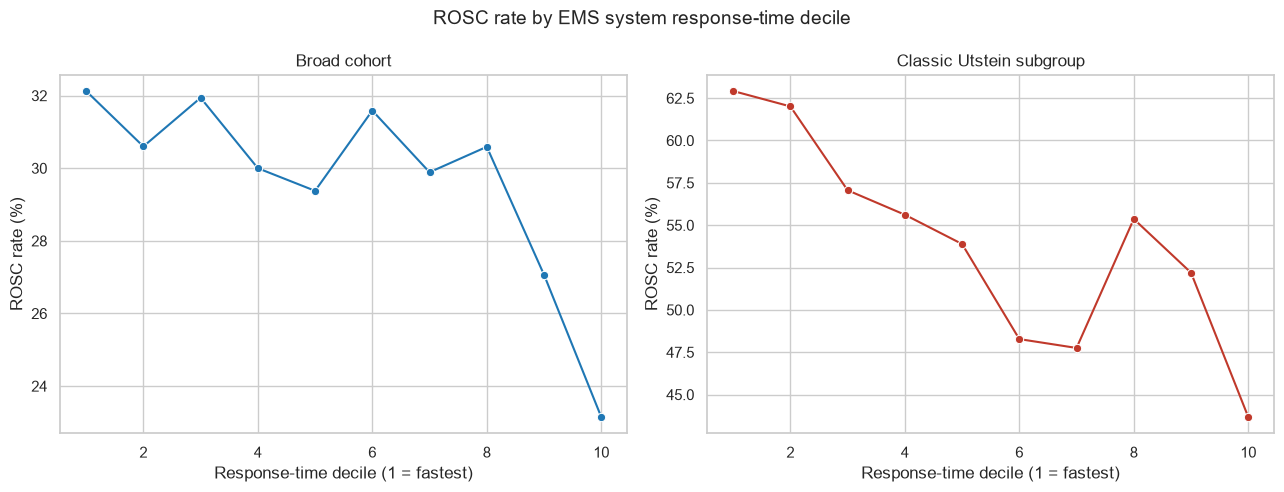

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

sns.lineplot(
    data=broad_deciles,
    x="response_decile",
    y="rosc_rate_pct",
    marker="o",
    ax=axes[0],
    color="#1f77b4",
)
axes[0].set_title("Broad cohort")
axes[0].set_xlabel("Response-time decile (1 = fastest)")
axes[0].set_ylabel("ROSC rate (%)")

sns.lineplot(
    data=classic_deciles,
    x="response_decile",
    y="rosc_rate_pct",
    marker="o",
    ax=axes[1],
    color="#c0392b",
)
axes[1].set_title("Classic Utstein subgroup")
axes[1].set_xlabel("Response-time decile (1 = fastest)")
axes[1].set_ylabel("ROSC rate (%)")

fig.suptitle("ROSC rate by EMS system response-time decile", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rosc_by_response_decile.png", dpi=200, bbox_inches="tight")
plt.show()


,initial_rhythm,records,rosc_rate_pct
0,Asystole,8834,17.34
1,PEA,3782,39.29
2,Ventricular fibrillation,1997,46.57
3,Unknown AED non-shockable rhythm,1016,37.99
4,Not recorded,631,41.68
5,Unknown AED shockable rhythm,516,53.88
6,Pulseless ventricular tachycardia,286,57.34
7,Not applicable,136,42.65


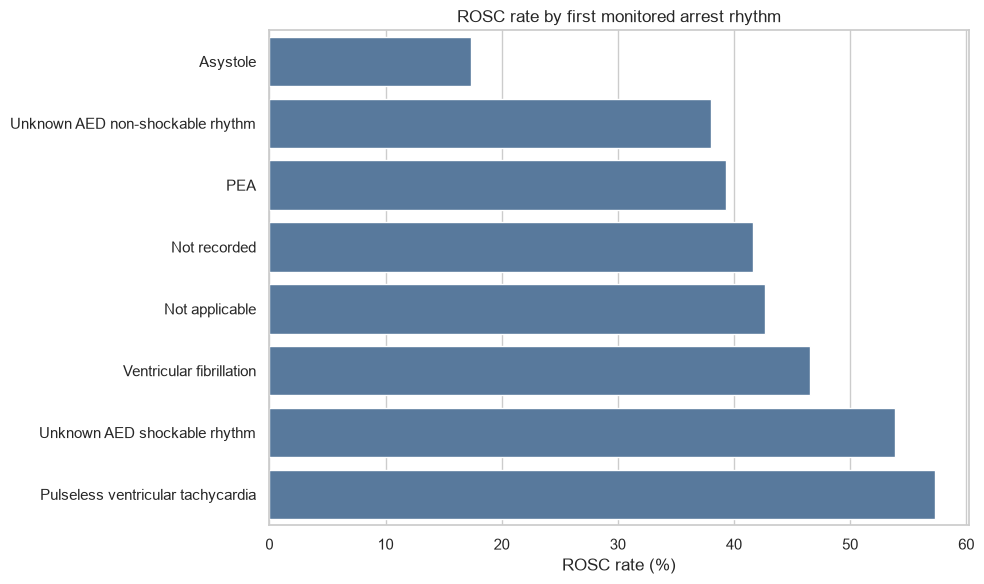

In [7]:
rhythm_summary = (
    df.groupby("initial_rhythm", observed=False)["rosc"]
    .agg(records="size", rosc_rate_pct=lambda values: 100 * values.mean())
    .sort_values("records", ascending=False)
    .reset_index()
)
display(rhythm_summary.round(2))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=rhythm_summary.sort_values("rosc_rate_pct", ascending=True),
    x="rosc_rate_pct",
    y="initial_rhythm",
    color="#4c78a8",
)
plt.title("ROSC rate by first monitored arrest rhythm")
plt.xlabel("ROSC rate (%)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rosc_by_initial_rhythm.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Modeling strategy

Two algorithms are compared:

1. **Logistic regression**, providing a transparent linear baseline.
2. **Random forest**, allowing nonlinear response-time thresholds and interactions.

For each algorithm, a baseline feature set is compared with an enhanced set that adds EMS system response time. All reported metrics come from five-fold stratified cross-validated predictions. ROC AUC and average precision are emphasized because ordinary accuracy can be misleading in the imbalanced broad cohort.


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

BASE_NUMERIC_FEATURES = ["age_years"]
BASE_CATEGORICAL_FEATURES = [
    "urbanicity",
    "census_region",
    "arrest_etiology",
    "witness_category",
    "aed_use_prior_ems",
    "initial_rhythm",
]
RESPONSE_FEATURE = "response_time_minutes"


def build_pipeline(algorithm, include_response):
    numeric_features = list(BASE_NUMERIC_FEATURES)
    if include_response:
        numeric_features.append(RESPONSE_FEATURE)

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if algorithm == "logistic_regression":
        numeric_steps.append(("scaler", StandardScaler()))

    preprocessing = ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(numeric_steps), numeric_features),
            (
                "categorical",
                Pipeline(
                    [
                        (
                            "imputer",
                            SimpleImputer(strategy="constant", fill_value="Missing"),
                        ),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                BASE_CATEGORICAL_FEATURES,
            ),
        ]
    )

    if algorithm == "logistic_regression":
        model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    elif algorithm == "random_forest":
        model = RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=10,
            max_features="sqrt",
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")

    return Pipeline([("preprocessing", preprocessing), ("model", model)])


def evaluate_model(data, cohort_name, algorithm, include_response):
    numeric_features = list(BASE_NUMERIC_FEATURES)
    if include_response:
        numeric_features.append(RESPONSE_FEATURE)
    features = numeric_features + BASE_CATEGORICAL_FEATURES
    x = data[features]
    y = data["rosc"].astype(int)

    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    pipeline = build_pipeline(algorithm, include_response)
    probabilities = cross_val_predict(
        pipeline, x, y, cv=folds, method="predict_proba", n_jobs=1
    )[:, 1]
    predictions = (probabilities >= 0.5).astype(int)

    return {
        "cohort": cohort_name,
        "algorithm": algorithm,
        "response_time": "included" if include_response else "excluded",
        "records": len(y),
        "roc_auc": roc_auc_score(y, probabilities),
        "average_precision": average_precision_score(y, probabilities),
        "accuracy": accuracy_score(y, predictions),
        "balanced_accuracy": balanced_accuracy_score(y, predictions),
        "f1": f1_score(y, predictions),
    }


In [9]:
cohorts = {
    "broad": df.copy(),
    "classic_utstein": classic_df.copy(),
}

model_results = []
for cohort_name, cohort_data in cohorts.items():
    for algorithm in ["logistic_regression", "random_forest"]:
        for include_response in [False, True]:
            print(
                f"Evaluating {cohort_name}: {algorithm}, "
                f"response_time={include_response}"
            )
            model_results.append(
                evaluate_model(
                    cohort_data,
                    cohort_name,
                    algorithm,
                    include_response,
                )
            )

results = pd.DataFrame(model_results)
results.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
display(results.round(4))


Evaluating broad: logistic_regression, response_time=False


Evaluating broad: logistic_regression, response_time=True


Evaluating broad: random_forest, response_time=False


Evaluating broad: random_forest, response_time=True


Evaluating classic_utstein: logistic_regression, response_time=False
Evaluating classic_utstein: logistic_regression, response_time=True


Evaluating classic_utstein: random_forest, response_time=False


Evaluating classic_utstein: random_forest, response_time=True


,cohort,algorithm,response_time,records,roc_auc,average_precision,accuracy,balanced_accuracy,f1
0,broad,logistic_regression,excluded,17198,0.7215,0.4946,0.7196,0.5893,0.3628
1,broad,logistic_regression,included,17198,0.7242,0.4981,0.7217,0.5959,0.3794
2,broad,random_forest,excluded,17198,0.7287,0.5075,0.6540,0.6776,0.5575
3,broad,random_forest,included,17198,0.7323,0.5154,0.6596,0.6801,0.5598
4,classic_utstein,logistic_regression,excluded,1777,0.5947,0.6129,0.5774,0.5682,0.6363
5,classic_utstein,logistic_regression,included,1777,0.6049,0.6154,0.5853,0.5758,0.6441
6,classic_utstein,random_forest,excluded,1777,0.5963,0.6223,0.5751,0.5753,0.5926
7,classic_utstein,random_forest,included,1777,0.6076,0.6291,0.5808,0.5787,0.6089


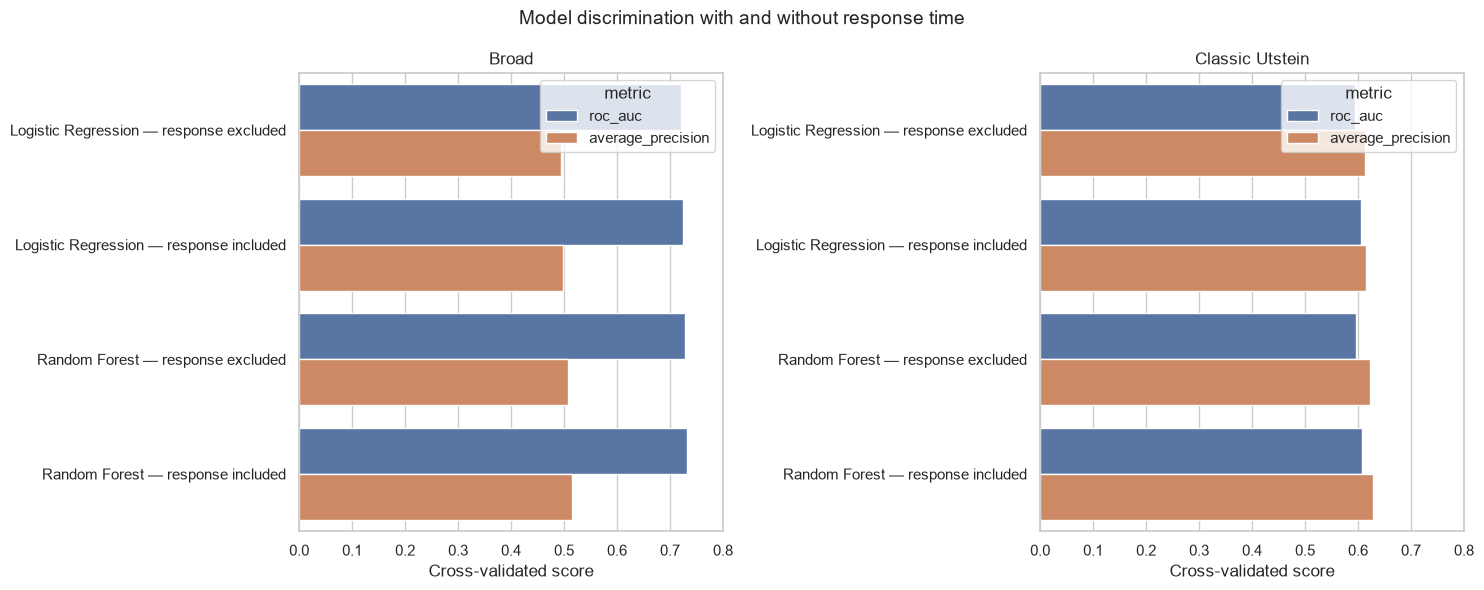

In [10]:
plot_results = results.copy()
plot_results["model"] = (
    plot_results["algorithm"].str.replace("_", " ").str.title()
    + " — response "
    + plot_results["response_time"]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)
for axis, cohort_name in zip(axes, ["broad", "classic_utstein"]):
    subset = plot_results.loc[plot_results["cohort"].eq(cohort_name)]
    chart = subset.melt(
        id_vars=["model"],
        value_vars=["roc_auc", "average_precision"],
        var_name="metric",
        value_name="score",
    )
    sns.barplot(data=chart, x="score", y="model", hue="metric", ax=axis)
    axis.set_title(cohort_name.replace("_", " ").title())
    axis.set_xlabel("Cross-validated score")
    axis.set_ylabel("")
    axis.set_xlim(0, 0.8)

fig.suptitle("Model discrimination with and without response time", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_metric_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Descriptive feature importance for the leading model

,feature,importance
38,categorical__initial_rhythm_Asystole,0.278047
32,categorical__witness_category_Not witnessed,0.174308
1,numeric__response_time_minutes,0.071276
28,categorical__witness_category_Healthcare provider,0.070328
0,numeric__age_years,0.060023
45,categorical__initial_rhythm_Ventricular fibril...,0.042605
41,categorical__initial_rhythm_PEA,0.042274
21,categorical__arrest_etiology_Traumatic cause,0.032682
24,categorical__witness_category_Family member,0.030144
20,categorical__arrest_etiology_Respiratory/asphyxia,0.020434


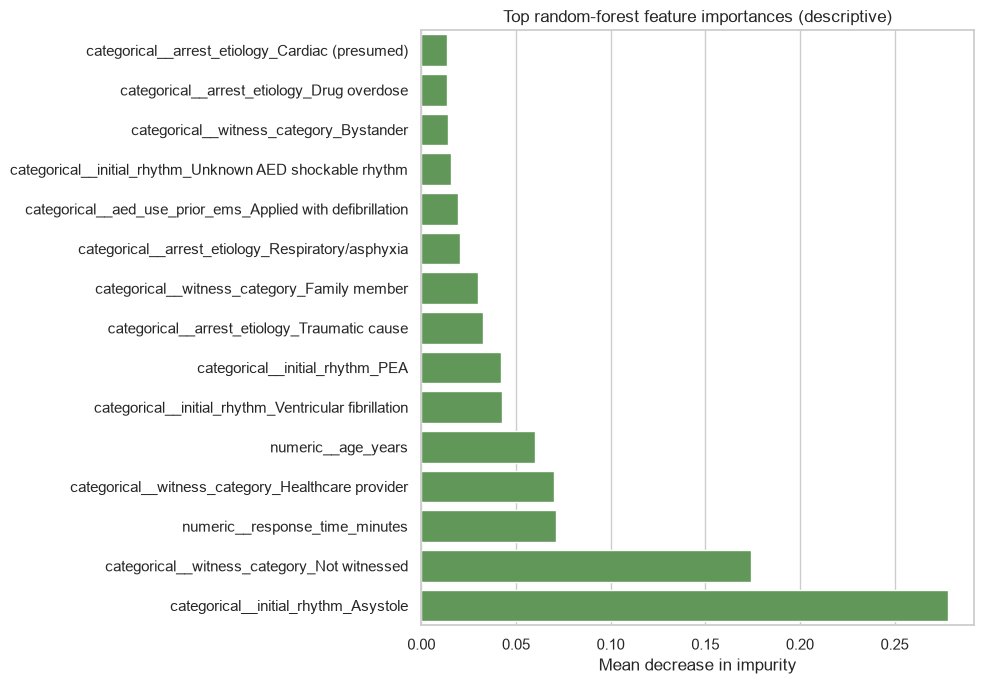

In [11]:
leading_pipeline = build_pipeline("random_forest", include_response=True)
leading_features = (
    BASE_NUMERIC_FEATURES + [RESPONSE_FEATURE] + BASE_CATEGORICAL_FEATURES
)
leading_pipeline.fit(df[leading_features], df["rosc"].astype(int))

feature_names = leading_pipeline.named_steps["preprocessing"].get_feature_names_out()
feature_importances = leading_pipeline.named_steps["model"].feature_importances_
importance_table = (
    pd.DataFrame(
        {"feature": feature_names, "importance": feature_importances}
    )
    .sort_values("importance", ascending=False)
    .head(15)
)
display(importance_table)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=importance_table.sort_values("importance", ascending=True),
    x="importance",
    y="feature",
    color="#59a14f",
)
plt.title("Top random-forest feature importances (descriptive)")
plt.xlabel("Mean decrease in impurity")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "random_forest_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()


## 6. Findings

- In the broad cohort, adding response time improved logistic ROC AUC from approximately **0.7215 to 0.7241** and random-forest ROC AUC from **0.7289 to 0.7321**.
- In the classic Utstein subgroup, the response-time contribution was larger: logistic ROC AUC increased from approximately **0.5947 to 0.6049**, while random-forest ROC AUC increased from **0.5933 to 0.6095**.
- The enhanced random forest produced the highest ROC AUC and average precision in both cohorts.
- In the classic Utstein descriptive analysis, ROSC was approximately **62.9% in the fastest response-time decile** and **43.7% in the slowest decile**.
- Response time added consistent but modest predictive information. Initial rhythm and other resuscitation characteristics remained major predictors.

## 7. Limitations

- The NEMSIS research dataset is a convenience sample, not a population-based dataset.
- Records represent EMS activations rather than unique patients or incidents. Multiple responding agencies may submit records for one event.
- First-unit status identifies the first unit for the reporting EMS agency and may not always identify the first responder from every agency.
- Missing and “not recorded” values may introduce information bias.
- ROSC is an intermediate outcome and must not be described as survival to hospital discharge.
- This observational predictive analysis cannot establish that longer response time caused a lower probability of ROSC.
- Random-forest impurity importance is descriptive and can favor continuous or high-cardinality predictors.

## 8. Conclusion

EMS system response time improved ROSC prediction in both cohorts, with a more visible contribution in the classic presumed-cardiac Utstein-style subgroup. The results support treating response time as one component of cardiac-arrest outcome modeling while preserving the larger influence of rhythm, witness status, pre-arrival AED use, etiology, age, and geography.


In [12]:
print("Notebook analysis complete.")
print(f"Saved figures: {FIGURES_DIR.resolve()}")
print(f"Saved aggregate results: {(RESULTS_DIR / 'model_comparison.csv').resolve()}")


Notebook analysis complete.
Saved figures: C:\Users\rirgmc\repos\machine-learning-project\figures
Saved aggregate results: C:\Users\rirgmc\repos\machine-learning-project\results\model_comparison.csv
